In [4]:
from dataclasses import (
    dataclass,
    field,
)

from jax import (
    config,
    hessian,
)
import jax.numpy as jnp
import jax.random as jr
from jaxtyping import (
    Array,
    Float,
    install_import_hook,
)
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpyro.distributions as npd
import pandas as pd

from gpjax.kernels.computations import DenseKernelComputation

config.update("jax_enable_x64", True)


with install_import_hook("gpjax", "beartype.beartype"):
    import gpjax as gpx
    from gpjax.parameters import Parameter

key = jr.key(42)

colors = rcParams["axes.prop_cycle"].by_key()["color"]

In [5]:
# function to place data from csv into correct array shape
def prepare_data(df):
    pos = jnp.array([df["lon"], df["lat"]])
    vel = jnp.array([df["ubar"], df["vbar"]])
    # extract shape stored as 'metadata' in the test data
    try:
        shape = (int(df["shape"][1]), int(df["shape"][0]))  # shape = (34,16)
        return pos, vel, shape
    except KeyError:
        return pos, vel


# loading in data

gulf_data_train = pd.read_csv(
    "https://raw.githubusercontent.com/JaxGaussianProcesses/static/main/data/gulfdata_train.csv"
)
gulf_data_test = pd.read_csv(
    "https://raw.githubusercontent.com/JaxGaussianProcesses/static/main/data/gulfdata_test.csv"
)

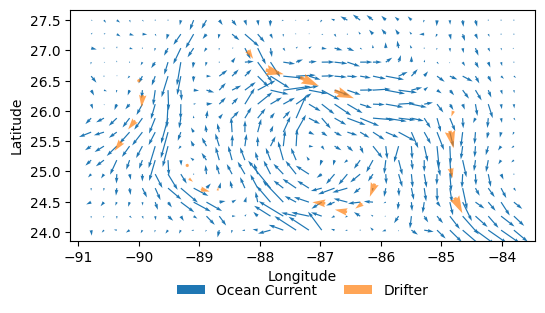

In [6]:
pos_test, vel_test, shape = prepare_data(gulf_data_test)
pos_train, vel_train = prepare_data(gulf_data_train)

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.quiver(
    pos_test[0],
    pos_test[1],
    vel_test[0],
    vel_test[1],
    color=colors[0],
    label="Ocean Current",
    angles="xy",
    scale=10,
)
ax.quiver(
    pos_train[0],
    pos_train[1],
    vel_train[0],
    vel_train[1],
    color=colors[1],
    alpha=0.7,
    label="Drifter",
    angles="xy",
    scale=10,
)

ax.set(
    xlabel="Longitude",
    ylabel="Latitude",
)
ax.legend(
    framealpha=0.0,
    ncols=2,
    fontsize="medium",
    bbox_to_anchor=(0.5, -0.3),
    loc="lower center",
)

In [7]:
# %%
# Change vectors x -> X = (x,z), and vectors y -> Y = (y,z) via the artificial z label
def label_position(data):
    # introduce alternating z label
    n_points = len(data[0])
    label = jnp.tile(jnp.array([0.0, 1.0]), n_points)
    return jnp.vstack((jnp.repeat(data, repeats=2, axis=1), label)).T


# change vectors y -> Y by reshaping the velocity measurements
def stack_velocity(data):
    return data.T.flatten().reshape(-1, 1)


def dataset_3d(pos, vel):
    return gpx.Dataset(label_position(pos), stack_velocity(vel))


# label and place the training data into a Dataset object to be used by GPJax
dataset_train = dataset_3d(pos_train, vel_train)

# we also require the testing data to be relabelled for later use, such that we can query the 2Nx2N GP at the test points
dataset_ground_truth = dataset_3d(pos_test, vel_test)

In [8]:
class VelocityKernel(gpx.kernels.AbstractKernel):
    def __init__(
        self,
        kernel0: gpx.kernels.AbstractKernel = gpx.kernels.RBF(active_dims=[0, 1]),
        kernel1: gpx.kernels.AbstractKernel = gpx.kernels.RBF(active_dims=[0, 1]),
    ):
        self.kernel0 = kernel0
        self.kernel1 = kernel1
        super().__init__(compute_engine=DenseKernelComputation())

    def __call__(
        self, X: Float[Array, "1 D"], Xp: Float[Array, "1 D"]
    ) -> Float[Array, "1"]:
        # standard RBF-SE kernel is x and x' are on the same output, otherwise returns 0

        z = jnp.array(X[2], dtype=int)
        zp = jnp.array(Xp[2], dtype=int)

        # achieve the correct value via 'switches' that are either 1 or 0
        k0_switch = ((z + 1) % 2) * ((zp + 1) % 2)
        k1_switch = z * zp

        return k0_switch * self.kernel0(X, Xp) + k1_switch * self.kernel1(X, Xp)

In [9]:
# %%
def initialise_gp(kernel, mean, dataset):
    prior = gpx.gps.Prior(mean_function=mean, kernel=kernel)
    likelihood = gpx.likelihoods.Gaussian(
        num_datapoints=dataset.n, obs_stddev=jnp.array([1.0e-3], dtype=jnp.float64)
    )
    posterior = prior * likelihood
    return posterior

In [10]:
# Define the velocity GP
mean = gpx.mean_functions.Zero()
kernel = VelocityKernel()
velocity_posterior = initialise_gp(kernel, mean, dataset_train)

In [11]:
def optimise_mll(posterior, dataset, NIters=1000, key=key):
    # define the MLL using dataset_train
    objective = lambda p, d: -gpx.objectives.conjugate_mll(p, d)
    # Optimise to minimise the MLL
    opt_posterior, history = gpx.fit_scipy(
        model=posterior,
        objective=objective,
        train_data=dataset,
        trainable=Parameter,
    )
    return opt_posterior

In [12]:
opt_velocity_posterior = optimise_mll(velocity_posterior, dataset_train)

Optimization terminated successfully.
         Current function value: -26.620707
         Iterations: 42
         Function evaluations: 70
         Gradient evaluations: 70


In [13]:
def latent_distribution(opt_posterior, pos_3d, dataset_train):
    latent = opt_posterior.predict(pos_3d, train_data=dataset_train)
    latent_mean = latent.mean
    latent_std = latent.stddev()
    return latent_mean, latent_std


# extract latent mean and std of g, redistribute into vectors to model F
velocity_mean, velocity_std = latent_distribution(
    opt_velocity_posterior, dataset_ground_truth.X, dataset_train
)

dataset_latent_velocity = dataset_3d(pos_test, velocity_mean)

In [14]:
def plot_vector_field(ax, dataset, **kwargs):
    ax.quiver(
        dataset.X[::2][:, 0],
        dataset.X[::2][:, 1],
        dataset.y[::2],
        dataset.y[1::2],
        **kwargs,
    )


def prepare_ax(ax, X, Y, title, **kwargs):
    ax.set(
        xlim=[X.min() - 0.1, X.max() + 0.1],
        ylim=[Y.min() + 0.1, Y.max() + 0.1],
        aspect="equal",
        title=title,
        ylabel="latitude",
        **kwargs,
    )


def residuals(dataset_latent, dataset_ground_truth):
    return jnp.sqrt(
        (dataset_latent.y[::2] - dataset_ground_truth.y[::2]) ** 2
        + (dataset_latent.y[1::2] - dataset_ground_truth.y[1::2]) ** 2
    )


def plot_fields(
    dataset_ground_truth, dataset_trajectory, dataset_latent, shape=shape, scale=10
):
    X = dataset_ground_truth.X[:, 0][::2]
    Y = dataset_ground_truth.X[:, 1][::2]
    # make figure
    fig, ax = plt.subplots(1, 3, figsize=(12.0, 3.0), sharey=True)

    # ground truth
    plot_vector_field(
        ax[0],
        dataset_ground_truth,
        color=colors[0],
        label="Ocean Current",
        angles="xy",
        scale=scale,
    )
    plot_vector_field(
        ax[0],
        dataset_trajectory,
        color=colors[1],
        label="Drifter",
        angles="xy",
        scale=scale,
    )
    prepare_ax(ax[0], X, Y, "Ground Truth", xlabel="Longitude")

    # Latent estimate of vector field F
    plot_vector_field(ax[1], dataset_latent, color=colors[0], angles="xy", scale=scale)
    plot_vector_field(
        ax[1], dataset_trajectory, color=colors[1], angles="xy", scale=scale
    )
    prepare_ax(ax[1], X, Y, "GP Estimate", xlabel="Longitude")

    # residuals
    residuals_vel = jnp.flip(
        residuals(dataset_latent, dataset_ground_truth).reshape(shape), axis=0
    )
    im = ax[2].imshow(
        residuals_vel,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        cmap="jet",
        vmin=0,
        vmax=1.0,
        interpolation="spline36",
    )
    plot_vector_field(
        ax[2], dataset_trajectory, color=colors[1], angles="xy", scale=scale
    )
    prepare_ax(ax[2], X, Y, "Residuals", xlabel="Longitude")
    fig.colorbar(im, fraction=0.027, pad=0.04, orientation="vertical")

    fig.legend(
        framealpha=0.0,
        ncols=2,
        fontsize="medium",
        bbox_to_anchor=(0.5, -0.03),
        loc="lower center",
    )

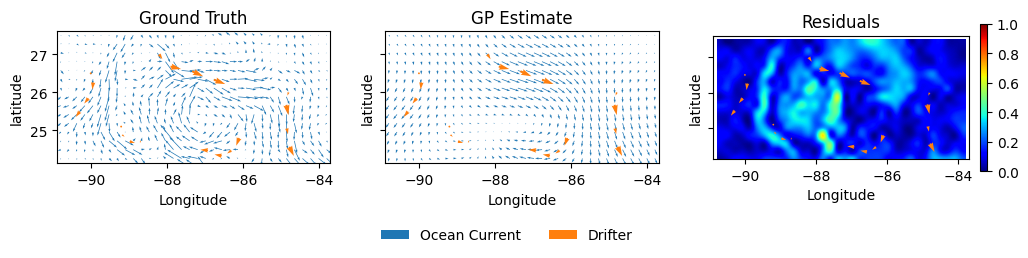

In [15]:
plot_fields(dataset_ground_truth, dataset_train, dataset_latent_velocity)

In [16]:
@dataclass
class HelmholtzKernel(gpx.kernels.stationary.StationaryKernel):
    # initialise Phi and Psi kernels as any stationary kernel in gpJax
    potential_kernel: gpx.kernels.stationary.StationaryKernel = field(
        default_factory=lambda: gpx.kernels.RBF(active_dims=[0, 1])
    )
    stream_kernel: gpx.kernels.stationary.StationaryKernel = field(
        default_factory=lambda: gpx.kernels.RBF(active_dims=[0, 1])
    )
    compute_engine = DenseKernelComputation()

    def __call__(
        self, X: Float[Array, "1 D"], Xp: Float[Array, "1 D"]
    ) -> Float[Array, "1"]:
        # obtain indices for k_helm, implement in the correct sign between the derivatives
        z = jnp.array(X[2], dtype=int)
        zp = jnp.array(Xp[2], dtype=int)
        sign = (-1) ** (z + zp)

        # convert to array to correctly index, -ve sign due to exchange symmetry (only true for stationary kernels)
        potential_dvtve = -jnp.array(
            hessian(self.potential_kernel)(X, Xp), dtype=jnp.float64
        )[z][zp]
        stream_dvtve = -jnp.array(
            hessian(self.stream_kernel)(X, Xp), dtype=jnp.float64
        )[1 - z][1 - zp]

        return potential_dvtve + sign * stream_dvtve

In [17]:
kernel = HelmholtzKernel()
helmholtz_posterior = initialise_gp(kernel, mean, dataset_train)
# Optimise hyperparameters using BFGS
opt_helmholtz_posterior = optimise_mll(helmholtz_posterior, dataset_train)

Optimization terminated successfully.
         Current function value: -28.611975
         Iterations: 35
         Function evaluations: 58
         Gradient evaluations: 58


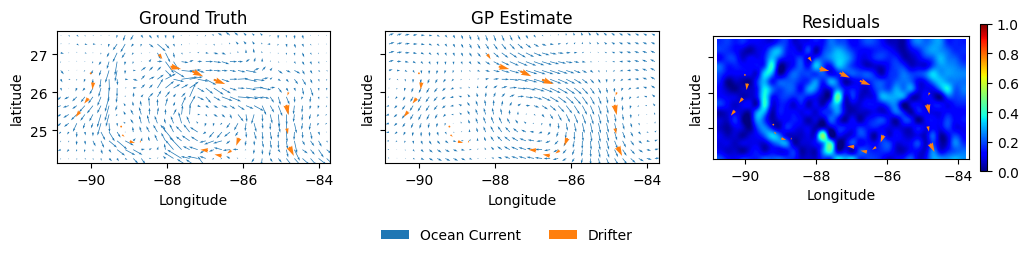

In [18]:
helmholtz_mean, helmholtz_std = latent_distribution(
    opt_helmholtz_posterior, dataset_ground_truth.X, dataset_train
)
dataset_latent_helmholtz = dataset_3d(pos_test, helmholtz_mean)

plot_fields(dataset_ground_truth, dataset_train, dataset_latent_helmholtz)

In [19]:
def nlpd(mean, std, vel_test):
    vel_query = jnp.column_stack((vel_test[0], vel_test[1])).flatten()
    normal = npd.Normal(loc=mean, scale=std)
    return -jnp.sum(normal.log_prob(vel_query))


# compute nlpd for velocity and helmholtz
nlpd_vel = nlpd(velocity_mean, velocity_std, vel_test)
nlpd_helm = nlpd(helmholtz_mean, helmholtz_std, vel_test)

print("NLPD for Velocity: %.2f \nNLPD for Helmholtz: %.2f" % (nlpd_vel, nlpd_helm))

NLPD for Velocity: 730.13 
NLPD for Helmholtz: -280.59
